TensorFlow 版本: 2.18.0

当前数据目录: C:\Users\lenovo\Desktop\研二\人工系统

文件检查:
chb08-summary.txt 存在
chb08_02.edf 存在
chb08_03.edf 存在
chb08_05.edf 存在
chb08_11.edf 存在

summary 文件读取成功。

小波图像数据集文件夹:
C:\Users\lenovo\Desktop\研二\人工系统\eeg_wavelet_dataset

测试 EDF 读取:
EDF 通道数量: 23
前 5 个通道: ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3']
前 5 个采样率: [256. 256. 256. 256. 256.]
文件总时长: 3600.0 秒
测试 EEG 片段长度: (2560,)
测试 EEG 采样率: 256.0

当前已有图像数量:
seizure: 0
non_seizure: 0

开始重新生成小波图像...

开始生成 seizure 小波图像...
seizure 已生成: 10/50
seizure 已生成: 20/50
seizure 已生成: 30/50
seizure 已生成: 40/50
seizure 已生成: 50/50

开始生成 non_seizure 小波图像...
non_seizure 已生成: 10/50
non_seizure 已生成: 20/50
non_seizure 已生成: 30/50
non_seizure 已生成: 40/50
non_seizure 已生成: 50/50

小波图像生成完成。

最终图像数量:
seizure: 50
non_seizure: 50
总数: 100


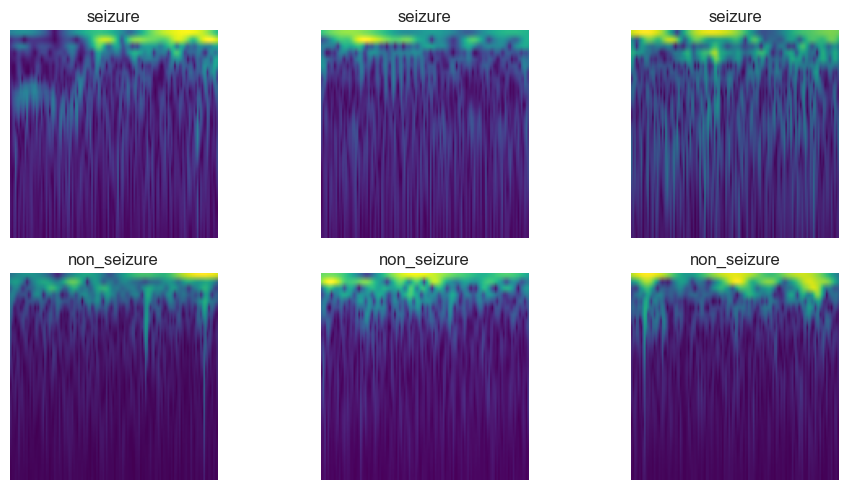


开始构建 CNN 数据集...


UnicodeDecodeError: 'utf-8' codec can't decode byte 0x8c in position 29: invalid start byte

In [5]:
# ============================================================
# EEG Seizure Detection with Wavelet Images + CNN
# CHB-MIT chb08
#
# 功能：
# 1. 纯 Python 读取 EDF 文件
# 2. 避免 utf-8 编码读取 EDF 导致 UnicodeDecodeError
# 3. 生成 EEG 小波图像
# 4. 构建 CNN 神经网络
# 5. 训练模型并输出训练过程
# 6. 绘制准确率曲线和损失曲线
# 7. 输出验证集准确率、混淆矩阵、分类报告
#
# 不使用：
# mne, pywt, pyedflib, edfio
#
# 需要文件：
# chb08-summary.txt
# chb08_02.edf
# chb08_03.edf
# chb08_05.edf
# chb08_11.edf
# ============================================================


# ============================================================
# 1. 导入库
# ============================================================

import os
import random
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

print("TensorFlow 版本:", tf.__version__)


# ============================================================
# 2. 基本参数
# ============================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 第一次运行建议 True
# 如果已经生成过小波图像，可以改成 False
REGENERATE_IMAGES = True

# EEG 片段长度，单位：秒
WINDOW_SEC = 10

# 每类图像数量
TARGET_PER_CLASS = 50

# 有发作片段滑动步长
SEIZURE_STEP_SEC = 5

# 无发作片段滑动步长
NON_SEIZURE_STEP_SEC = 10

# 目标 EEG 通道
TARGET_CHANNEL = "FP1-F7"

# 小波图像尺寸
IMG_SIZE = 128

# 小波参数
FREQ_MIN = 1
FREQ_MAX = 50
N_FREQS = 32
N_CYCLES = 6

# CNN 参数
BATCH_SIZE = 16
EPOCHS = 20


# ============================================================
# 3. 路径检查
# ============================================================

BASE_DIR = Path.cwd()

if not (BASE_DIR / "chb08-summary.txt").exists() and Path("/mnt/data/chb08-summary.txt").exists():
    BASE_DIR = Path("/mnt/data")

print("\n当前数据目录:", BASE_DIR)

required_files = [
    "chb08-summary.txt",
    "chb08_02.edf",
    "chb08_03.edf",
    "chb08_05.edf",
    "chb08_11.edf"
]

print("\n文件检查:")
missing_files = []

for file_name in required_files:
    file_path = BASE_DIR / file_name
    if file_path.exists():
        print(file_name, "存在")
    else:
        print(file_name, "不存在")
        missing_files.append(file_name)

if missing_files:
    raise FileNotFoundError(
        "以下文件不存在，请把它们放到 notebook 同一文件夹：\n"
        + "\n".join(missing_files)
    )


# ============================================================
# 4. 安全读取 summary 文件，避免 UnicodeDecodeError
# ============================================================

summary_path = BASE_DIR / "chb08-summary.txt"

try:
    with open(summary_path, "r", encoding="utf-8") as f:
        summary_text = f.read()
except UnicodeDecodeError:
    with open(summary_path, "r", encoding="latin-1", errors="ignore") as f:
        summary_text = f.read()

print("\nsummary 文件读取成功。")


# ============================================================
# 5. 根据 chb08-summary.txt 设置标签
# ============================================================

# 有癫痫发作的 EDF 文件及发作时间
SEIZURE_INFO = {
    "chb08_02.edf": [(2670, 2841)],
    "chb08_05.edf": [(2856, 3046)],
    "chb08_11.edf": [(2988, 3122)],
}

# 无癫痫发作 EDF 文件
NON_SEIZURE_FILES = [
    "chb08_03.edf"
]


# ============================================================
# 6. 输出文件夹
# ============================================================

DATASET_DIR = BASE_DIR / "eeg_wavelet_dataset"
SEIZURE_DIR = DATASET_DIR / "seizure"
NON_SEIZURE_DIR = DATASET_DIR / "non_seizure"

SEIZURE_DIR.mkdir(parents=True, exist_ok=True)
NON_SEIZURE_DIR.mkdir(parents=True, exist_ok=True)

print("\n小波图像数据集文件夹:")
print(DATASET_DIR)


# ============================================================
# 7. 纯 Python EDF 读取器
# ============================================================

class SimpleEDFReader:
    """
    简单 EDF 读取器。
    适用于 CHB-MIT 标准 EDF 文件。
    不依赖 mne、pyedflib、edfio。

    关键修正：
    1. EDF 文件必须用 rb 二进制读取；
    2. EDF 头信息不要用 utf-8 解码；
    3. 使用 latin-1 + errors='ignore'，避免 UnicodeDecodeError。
    """

    def __init__(self, file_path):
        self.file_path = str(file_path)
        self._read_header()

    def _read_ascii(self, f, n):
        raw = f.read(n)
        return raw.decode("latin-1", errors="ignore").strip()

    def _read_header(self):
        with open(self.file_path, "rb") as f:
            self.version = self._read_ascii(f, 8)
            self.patient_id = self._read_ascii(f, 80)
            self.recording_id = self._read_ascii(f, 80)
            self.start_date = self._read_ascii(f, 8)
            self.start_time = self._read_ascii(f, 8)

            self.header_bytes = int(self._read_ascii(f, 8))
            self.reserved = self._read_ascii(f, 44)
            self.num_records = int(self._read_ascii(f, 8))
            self.record_duration = float(self._read_ascii(f, 8))
            self.num_signals = int(self._read_ascii(f, 4))

            ns = self.num_signals

            self.labels = [self._read_ascii(f, 16) for _ in range(ns)]
            self.transducers = [self._read_ascii(f, 80) for _ in range(ns)]
            self.physical_dimensions = [self._read_ascii(f, 8) for _ in range(ns)]

            self.physical_min = np.array(
                [float(self._read_ascii(f, 8)) for _ in range(ns)],
                dtype=np.float64
            )
            self.physical_max = np.array(
                [float(self._read_ascii(f, 8)) for _ in range(ns)],
                dtype=np.float64
            )
            self.digital_min = np.array(
                [float(self._read_ascii(f, 8)) for _ in range(ns)],
                dtype=np.float64
            )
            self.digital_max = np.array(
                [float(self._read_ascii(f, 8)) for _ in range(ns)],
                dtype=np.float64
            )

            self.prefiltering = [self._read_ascii(f, 80) for _ in range(ns)]

            self.samples_per_record = np.array(
                [int(self._read_ascii(f, 8)) for _ in range(ns)],
                dtype=np.int64
            )

            self.signal_reserved = [self._read_ascii(f, 32) for _ in range(ns)]

        self.record_size_samples = int(np.sum(self.samples_per_record))

        if self.num_records <= 0:
            file_size = Path(self.file_path).stat().st_size
            data_bytes = file_size - self.header_bytes
            self.num_records = data_bytes // (self.record_size_samples * 2)

        self.sampling_rates = self.samples_per_record / self.record_duration

        self.scale = (
            self.physical_max - self.physical_min
        ) / (
            self.digital_max - self.digital_min
        )

        self.offset = self.physical_min - self.scale * self.digital_min

    def get_signal_labels(self):
        return self.labels

    def get_sample_frequency(self, channel_index):
        return float(self.sampling_rates[channel_index])

    def get_duration(self):
        return float(self.num_records * self.record_duration)

    def read_signal(self, channel_index, start_sample, n_samples):
        samples_per_record = int(self.samples_per_record[channel_index])

        end_sample = start_sample + n_samples

        start_record = start_sample // samples_per_record
        end_record = (end_sample - 1) // samples_per_record

        all_parts = []

        with open(self.file_path, "rb") as f:
            for rec in range(start_record, end_record + 1):
                record_start_byte = (
                    self.header_bytes
                    + rec * self.record_size_samples * 2
                )

                before_channel_samples = int(
                    np.sum(self.samples_per_record[:channel_index])
                )

                channel_start_byte = (
                    record_start_byte
                    + before_channel_samples * 2
                )

                f.seek(channel_start_byte)

                raw = np.fromfile(
                    f,
                    dtype="<i2",
                    count=samples_per_record
                )

                physical = (
                    raw.astype(np.float64) * self.scale[channel_index]
                    + self.offset[channel_index]
                )

                all_parts.append(physical)

        data = np.concatenate(all_parts)

        local_start = start_sample - start_record * samples_per_record
        local_end = local_start + n_samples

        return data[local_start:local_end].astype(np.float32)


# ============================================================
# 8. EDF 辅助函数
# ============================================================

edf_cache = {}

def normalize_channel_name(name):
    return (
        str(name)
        .upper()
        .replace("EEG", "")
        .replace(" ", "")
        .replace("-REF", "")
        .replace("-LE", "")
        .strip()
    )

def get_edf_reader(edf_file):
    if edf_file not in edf_cache:
        edf_path = BASE_DIR / edf_file
        edf_cache[edf_file] = SimpleEDFReader(edf_path)
    return edf_cache[edf_file]

def choose_channel(reader, target_channel=TARGET_CHANNEL):
    labels = reader.get_signal_labels()
    target_norm = normalize_channel_name(target_channel)

    for idx, label in enumerate(labels):
        label_norm = normalize_channel_name(label)

        if target_norm == label_norm:
            return idx, label

        if target_norm in label_norm or label_norm in target_norm:
            return idx, label

    print(f"没有找到 {target_channel}，使用第一个通道: {labels[0]}")
    return 0, labels[0]

def read_eeg_segment(edf_file, start_sec, duration_sec=WINDOW_SEC):
    reader = get_edf_reader(edf_file)

    channel_index, channel_name = choose_channel(reader, TARGET_CHANNEL)
    sfreq = reader.get_sample_frequency(channel_index)

    start_sample = int(start_sec * sfreq)
    n_samples = int(duration_sec * sfreq)

    eeg = reader.read_signal(
        channel_index=channel_index,
        start_sample=start_sample,
        n_samples=n_samples
    )

    eeg = eeg - np.mean(eeg)
    eeg = eeg / (np.std(eeg) + 1e-8)

    return eeg, sfreq

def get_edf_duration(edf_file):
    reader = get_edf_reader(edf_file)
    return reader.get_duration()


# ============================================================
# 9. 测试 EDF 读取
# ============================================================

print("\n测试 EDF 读取:")

test_reader = get_edf_reader("chb08_02.edf")

print("EDF 通道数量:", test_reader.num_signals)
print("前 5 个通道:", test_reader.labels[:5])
print("前 5 个采样率:", test_reader.sampling_rates[:5])
print("文件总时长:", test_reader.get_duration(), "秒")

test_signal, test_sfreq = read_eeg_segment(
    "chb08_02.edf",
    start_sec=2670,
    duration_sec=10
)

print("测试 EEG 片段长度:", test_signal.shape)
print("测试 EEG 采样率:", test_sfreq)


# ============================================================
# 10. Morlet 小波变换
# ============================================================

wavelet_cache = {}

def get_morlet_kernels(sfreq, freqs, n_cycles=N_CYCLES):
    key = (float(sfreq), tuple(np.round(freqs, 4)), n_cycles)

    if key in wavelet_cache:
        return wavelet_cache[key]

    kernels = []

    for freq in freqs:
        sigma_t = n_cycles / (2 * np.pi * freq)
        half_width = int(np.ceil(3 * sigma_t * sfreq))
        t = np.arange(-half_width, half_width + 1) / sfreq

        wavelet = (
            np.exp(2j * np.pi * freq * t)
            * np.exp(-(t ** 2) / (2 * sigma_t ** 2))
        )

        wavelet = wavelet / (
            np.sqrt(np.sum(np.abs(wavelet) ** 2)) + 1e-8
        )

        kernels.append(np.conj(wavelet[::-1]))

    wavelet_cache[key] = kernels
    return kernels

def morlet_cwt_power(eeg_signal, sfreq, freqs):
    eeg_signal = np.asarray(eeg_signal, dtype=np.float32)
    n_times = len(eeg_signal)

    power = np.zeros((len(freqs), n_times), dtype=np.float32)
    kernels = get_morlet_kernels(sfreq, freqs, N_CYCLES)

    for i, kernel in enumerate(kernels):
        conv = np.convolve(eeg_signal, kernel, mode="same")

        if len(conv) != n_times:
            center = len(conv) // 2
            start = center - n_times // 2
            conv = conv[start:start + n_times]

        power[i, :] = np.abs(conv)

    return power

def save_wavelet_image(eeg_signal, sfreq, out_path):
    freqs = np.linspace(FREQ_MIN, FREQ_MAX, N_FREQS)

    power = morlet_cwt_power(
        eeg_signal=eeg_signal,
        sfreq=sfreq,
        freqs=freqs
    )

    power = np.log1p(power)
    power = (power - power.min()) / (power.max() - power.min() + 1e-8)

    cmap = plt.get_cmap("viridis")
    rgb = cmap(power)[:, :, :3]
    rgb = (rgb * 255).astype(np.uint8)

    img = tf.image.resize(rgb, (IMG_SIZE, IMG_SIZE)).numpy().astype(np.uint8)

    tf.keras.utils.save_img(str(out_path), img)


# ============================================================
# 11. 生成图像窗口
# ============================================================

def select_evenly(items, n):
    if len(items) < n:
        raise ValueError(f"候选片段不足，需要 {n} 个，目前只有 {len(items)} 个。")

    idx = np.linspace(0, len(items) - 1, n).round().astype(int)
    return [items[i] for i in idx]

def build_seizure_windows():
    candidates = []

    for edf_file, ranges in SEIZURE_INFO.items():
        for start_sec, end_sec in ranges:
            starts = np.arange(
                start_sec,
                end_sec - WINDOW_SEC + 1,
                SEIZURE_STEP_SEC
            )

            for s in starts:
                candidates.append((edf_file, float(s)))

    return select_evenly(candidates, TARGET_PER_CLASS)

def build_non_seizure_windows():
    candidates = []

    for edf_file in NON_SEIZURE_FILES:
        duration = get_edf_duration(edf_file)

        starts = np.arange(
            60,
            duration - 60 - WINDOW_SEC,
            NON_SEIZURE_STEP_SEC
        )

        for s in starts:
            candidates.append((edf_file, float(s)))

    return select_evenly(candidates, TARGET_PER_CLASS)

def clear_old_images():
    for folder in [SEIZURE_DIR, NON_SEIZURE_DIR]:
        for old_img in folder.glob("*.png"):
            old_img.unlink()

def count_images():
    seizure_count = len(list(SEIZURE_DIR.glob("*.png")))
    non_count = len(list(NON_SEIZURE_DIR.glob("*.png")))
    return seizure_count, non_count

def generate_wavelet_dataset():
    clear_old_images()

    seizure_windows = build_seizure_windows()
    non_windows = build_non_seizure_windows()

    print("\n开始生成 seizure 小波图像...")

    for i, (edf_file, start_sec) in enumerate(seizure_windows, start=1):
        eeg_signal, sfreq = read_eeg_segment(edf_file, start_sec, WINDOW_SEC)
        out_path = SEIZURE_DIR / f"seizure_{i:03d}.png"
        save_wavelet_image(eeg_signal, sfreq, out_path)

        if i % 10 == 0:
            print(f"seizure 已生成: {i}/{TARGET_PER_CLASS}")

    print("\n开始生成 non_seizure 小波图像...")

    for i, (edf_file, start_sec) in enumerate(non_windows, start=1):
        eeg_signal, sfreq = read_eeg_segment(edf_file, start_sec, WINDOW_SEC)
        out_path = NON_SEIZURE_DIR / f"non_seizure_{i:03d}.png"
        save_wavelet_image(eeg_signal, sfreq, out_path)

        if i % 10 == 0:
            print(f"non_seizure 已生成: {i}/{TARGET_PER_CLASS}")

    print("\n小波图像生成完成。")


# ============================================================
# 12. 生成或读取已有图像
# ============================================================

seizure_count, non_count = count_images()

print("\n当前已有图像数量:")
print("seizure:", seizure_count)
print("non_seizure:", non_count)

if REGENERATE_IMAGES or seizure_count < TARGET_PER_CLASS or non_count < TARGET_PER_CLASS:
    print("\n开始重新生成小波图像...")
    generate_wavelet_dataset()
else:
    print("\n已有足够图像，跳过生成步骤。")

seizure_count, non_count = count_images()

print("\n最终图像数量:")
print("seizure:", seizure_count)
print("non_seizure:", non_count)
print("总数:", seizure_count + non_count)


# ============================================================
# 13. 显示样例小波图像
# ============================================================

def show_sample_images():
    seizure_imgs = sorted(SEIZURE_DIR.glob("*.png"))[:3]
    non_imgs = sorted(NON_SEIZURE_DIR.glob("*.png"))[:3]

    sample_imgs = seizure_imgs + non_imgs

    plt.figure(figsize=(10, 5))

    for i, img_path in enumerate(sample_imgs):
        img = plt.imread(img_path)

        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_path.parent.name)

    plt.tight_layout()
    plt.show()

show_sample_images()


# ============================================================
# 14. 构建 CNN 训练集和验证集
# ============================================================

print("\n开始构建 CNN 数据集...")

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    labels="inferred",
    label_mode="binary",
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    labels="inferred",
    label_mode="binary",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=False
)

class_names = train_ds.class_names

print("\n类别名称:", class_names)
print("注意：类别顺序由文件夹名称自动决定。")
print("一般情况下 non_seizure = 0, seizure = 1")

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(100, seed=SEED).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)


# ============================================================
# 15. 建立 CNN 神经网络
# ============================================================

model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Rescaling(1.0 / 255),

    layers.Conv2D(16, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("\nCNN 模型结构:")
model.summary()


# ============================================================
# 16. 模型训练
# ============================================================

print("\n开始训练 CNN 神经网络...")
print("下面的 Epoch 输出就是模型训练过程。")

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)


# ============================================================
# 17. 输出每轮训练结果
# ============================================================

print("\n每轮训练结果汇总:")
print("-" * 80)
print(f"{'Epoch':<8}{'Train Acc':<15}{'Val Acc':<15}{'Train Loss':<15}{'Val Loss':<15}")
print("-" * 80)

for i in range(len(history.history["accuracy"])):
    train_acc_i = history.history["accuracy"][i]
    val_acc_i = history.history["val_accuracy"][i]
    train_loss_i = history.history["loss"][i]
    val_loss_i = history.history["val_loss"][i]

    print(
        f"{i + 1:<8}"
        f"{train_acc_i:<15.4f}"
        f"{val_acc_i:<15.4f}"
        f"{train_loss_i:<15.4f}"
        f"{val_loss_i:<15.4f}"
    )

print("-" * 80)

print("\n最后一轮训练结果:")
print("Train Accuracy:", history.history["accuracy"][-1])
print("Validation Accuracy:", history.history["val_accuracy"][-1])
print("Train Loss:", history.history["loss"][-1])
print("Validation Loss:", history.history["val_loss"][-1])


# ============================================================
# 18. 绘制训练过程中的准确率曲线和损失曲线
# ============================================================

history_dict = history.history

train_acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
train_loss = history_dict["loss"]
val_loss = history_dict["val_loss"]

epochs_range = range(1, len(train_acc) + 1)

plt.figure(figsize=(14, 5))

# 准确率曲线
plt.subplot(1, 2, 1)
plt.plot(
    epochs_range,
    train_acc,
    marker="o",
    linewidth=2,
    label="Train Accuracy"
)
plt.plot(
    epochs_range,
    val_acc,
    marker="s",
    linewidth=2,
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.xticks(epochs_range)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

# 损失曲线
plt.subplot(1, 2, 2)
plt.plot(
    epochs_range,
    train_loss,
    marker="o",
    linewidth=2,
    label="Train Loss"
)
plt.plot(
    epochs_range,
    val_loss,
    marker="s",
    linewidth=2,
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.xticks(epochs_range)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


# ============================================================
# 19. 验证集评估
# ============================================================

val_loss_eval, val_acc_eval = model.evaluate(val_ds, verbose=0)

print("\n验证集最终评估:")
print(f"Validation Loss: {val_loss_eval:.4f}")
print(f"Validation Accuracy: {val_acc_eval:.4f}")


# ============================================================
# 20. 混淆矩阵和分类报告
# ============================================================

y_true = []
y_pred = []
y_prob = []

for images, labels in val_ds:
    probs = model.predict(images, verbose=0).reshape(-1)
    preds = (probs >= 0.5).astype(int)

    y_true.extend(labels.numpy().astype(int).reshape(-1))
    y_pred.extend(preds)
    y_prob.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = np.zeros((2, 2), dtype=int)

for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

print("\n混淆矩阵:")
print(cm)

print("\n混淆矩阵解释:")
print("[[TN, FP],")
print(" [FN, TP]]")
print("TN: 正确判断为 non_seizure")
print("FP: 把 non_seizure 错判为 seizure")
print("FN: 把 seizure 错判为 non_seizure")
print("TP: 正确判断为 seizure")

TN, FP = cm[0, 0], cm[0, 1]
FN, TP = cm[1, 0], cm[1, 1]

accuracy = (TP + TN) / max(TP + TN + FP + FN, 1)

precision_non = TN / max(TN + FN, 1)
recall_non = TN / max(TN + FP, 1)
f1_non = 2 * precision_non * recall_non / max(precision_non + recall_non, 1e-8)

precision_seizure = TP / max(TP + FP, 1)
recall_seizure = TP / max(TP + FN, 1)
f1_seizure = 2 * precision_seizure * recall_seizure / max(
    precision_seizure + recall_seizure,
    1e-8
)

print("\n分类报告:")
print(f"{'Class':<15}{'Precision':<12}{'Recall':<12}{'F1-score':<12}")
print("-" * 55)
print(f"{class_names[0]:<15}{precision_non:<12.4f}{recall_non:<12.4f}{f1_non:<12.4f}")
print(f"{class_names[1]:<15}{precision_seizure:<12.4f}{recall_seizure:<12.4f}{f1_seizure:<12.4f}")
print("-" * 55)
print(f"{'Accuracy':<15}{accuracy:<12.4f}")

print("\n重点关注 seizure 的 Recall:")
print(f"seizure recall = {recall_seizure:.4f}")


# ============================================================
# 21. 单张图片预测测试
# ============================================================

def predict_one_image(image_path):
    img = tf.keras.utils.load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE),
        color_mode="rgb"
    )

    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prob = model.predict(img_array, verbose=0)[0][0]

    pred_class = class_names[1] if prob >= 0.5 else class_names[0]

    print("\n测试图像:", image_path)
    print("预测概率:", float(prob))
    print("预测类别:", pred_class)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {pred_class}")
    plt.show()


sample_seizure_imgs = sorted(SEIZURE_DIR.glob("*.png"))
sample_non_imgs = sorted(NON_SEIZURE_DIR.glob("*.png"))

if len(sample_seizure_imgs) > 0:
    predict_one_image(sample_seizure_imgs[0])

if len(sample_non_imgs) > 0:
    predict_one_image(sample_non_imgs[0])


print("\n全部流程完成：EDF 读取 + 小波图像生成 + CNN 训练 + 准确率曲线 + 损失曲线 + 结果评估。")